In [3]:
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer


In [4]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

In [5]:
def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list

In [6]:
optimization_trial = 100
results_val = {}
results_train = {}

In [11]:
for _ in range(optimization_trial):
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list


val acc:0.12 | lr:1.5171959188312649e-06, weight decay:1.351535735453013e-06
val acc:0.19 | lr:0.0007796881204558914, weight decay:2.1959870663548213e-07
val acc:0.05 | lr:2.2111619660825065e-05, weight decay:4.96365349706056e-08
val acc:0.12 | lr:0.0008349677732288818, weight decay:3.8293222441484804e-08
val acc:0.14 | lr:5.630379044374974e-06, weight decay:7.96780020347833e-06
val acc:0.08 | lr:2.3736568348243686e-06, weight decay:2.8225385779786015e-08
val acc:0.09 | lr:2.0502582510824178e-05, weight decay:8.846664967662285e-05
val acc:0.27 | lr:0.0015145645759428632, weight decay:1.1300962205270244e-06
val acc:0.22 | lr:0.0011559731416596458, weight decay:2.3428584809404195e-07
val acc:0.1 | lr:0.00011681082404855746, weight decay:2.3897812861186243e-07
val acc:0.07 | lr:1.0679075094347514e-05, weight decay:4.041645466234634e-07
val acc:0.1 | lr:4.626449737170575e-06, weight decay:5.077600132740312e-06
val acc:0.14 | lr:0.0014568812663017813, weight decay:4.787050291985918e-07
val 

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

Best-1(val acc:0.81) | lr:0.009950371874082365, weight decay:5.352095182690571e-07
Best-2(val acc:0.8) | lr:0.008496003379268492, weight decay:8.117040306110661e-05
Best-3(val acc:0.76) | lr:0.007931233746059465, weight decay:3.676091401289524e-07
Best-4(val acc:0.75) | lr:0.007499564468104958, weight decay:1.469450642906531e-05
Best-5(val acc:0.74) | lr:0.007565128812538548, weight decay:9.21043747278413e-07
Best-6(val acc:0.74) | lr:0.007982591700201862, weight decay:5.2981079915229666e-05
Best-7(val acc:0.74) | lr:0.009248873048643613, weight decay:1.0500780806432974e-08
Best-8(val acc:0.73) | lr:0.00840193128302897, weight decay:1.2664195434520102e-07
Best-9(val acc:0.73) | lr:0.006748880503242327, weight decay:2.2711785272530966e-07
Best-10(val acc:0.72) | lr:0.007194760390944355, weight decay:2.2723228059153778e-06
Best-11(val acc:0.72) | lr:0.007370331537655942, weight decay:2.2933318775549417e-07
Best-12(val acc:0.72) | lr:0.005397858988639226, weight decay:1.2350323976681925e-

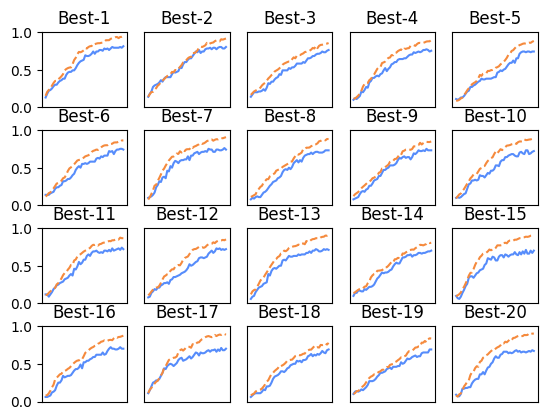

In [12]:
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

plt.figure(figsize=(10, 8))
for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()

val acc:0.67 | lr:0.006517992048970582, weight decay:1.972374444099225e-07
val acc:0.28 | lr:0.001459584181711764, weight decay:5.1609135457104224e-08
val acc:0.17 | lr:0.0010552147311137345, weight decay:2.8047217393930847e-07
val acc:0.56 | lr:0.005105739305208484, weight decay:2.413457668780942e-07
val acc:0.26 | lr:0.0010191486001498687, weight decay:2.434415247904279e-08
val acc:0.34 | lr:0.0016380485838397173, weight decay:9.404454669098077e-07
val acc:0.34 | lr:0.0013448874576856378, weight decay:1.891139889652248e-08
val acc:0.32 | lr:0.0010260937640219675, weight decay:2.83740153765926e-07
val acc:0.44 | lr:0.002467012456538046, weight decay:1.016376454129338e-07
val acc:0.69 | lr:0.006809208340953437, weight decay:5.079831934025162e-07
val acc:0.51 | lr:0.003392431524861323, weight decay:2.772630416910103e-07
val acc:0.5 | lr:0.002535026918187258, weight decay:6.589968760110691e-08
val acc:0.7 | lr:0.0041297814646405065, weight decay:9.11655034958381e-08
val acc:0.52 | lr:0.0

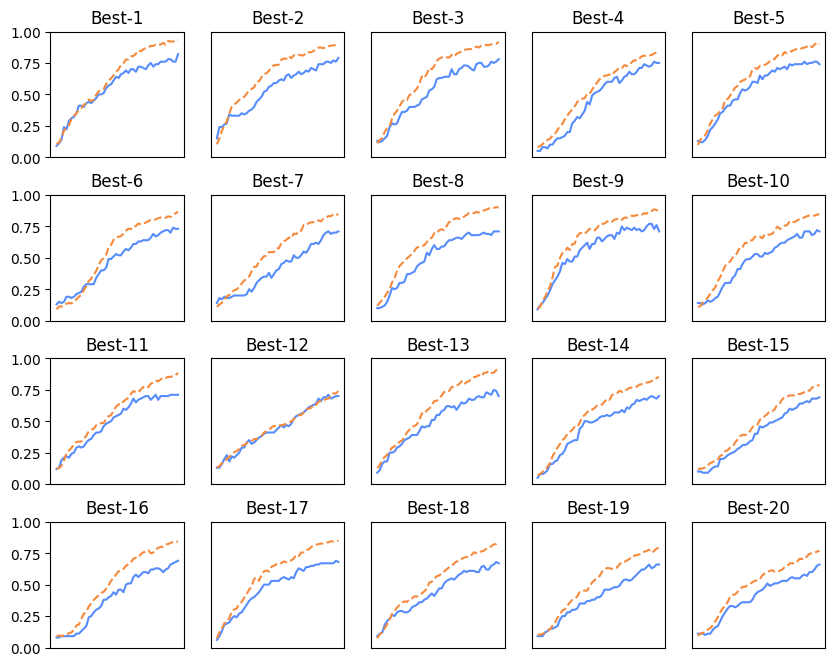

In [15]:
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    weight_decay = 10 ** np.random.uniform(-8, -6)
    lr = 10 ** np.random.uniform(-3, -2)

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

plt.figure(figsize=(10, 8))
for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()